In [1]:
# trek completions

In [1]:
import numpy as np
import pandas as pd

In [2]:
# import datasets

df = pd.read_csv("trek_completion.csv")
df.head()

,age,fitness_score,altitude_m,acclimatisation_days,pack_weight_kg,completed
0,23,8,4078,4,5.3,1
1,33,4,5233,0,14.3,0
2,30,9,4506,2,3.5,1
3,25,5,3859,0,19.0,0
4,51,3,3258,1,19.0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5000 non-null   int64  
 1   fitness_score         5000 non-null   int64  
 2   altitude_m            5000 non-null   int64  
 3   acclimatisation_days  5000 non-null   int64  
 4   pack_weight_kg        5000 non-null   float64
 5   completed             5000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 234.5 KB


In [4]:
df.shape

(5000, 6)

In [5]:
# separate inputs and output

X = df[['age','fitness_score','altitude_m','acclimatisation_days','pack_weight_kg']]
y = df['completed']

In [6]:
# split training and testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
# scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# build a model

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential([
    Input(shape=(5,)),
    Dense(1),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │               6 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6 (24.00 B)

 Trainable params: 6 (24.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# compile model

from tensorflow.keras.optimizers import Adam,SGD

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae"]
)

In [10]:
# Train model

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=4, 
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2187 - mae: 0.4037 - val_loss: 0.1405 - val_mae: 0.3169
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1467 - mae: 0.3225 - val_loss: 0.1419 - val_mae: 0.3158
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1467 - mae: 0.3226 - val_loss: 0.1435 - val_mae: 0.3185
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1465 - mae: 0.3218 - val_loss: 0.1421 - val_mae: 0.3173
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1470 - mae: 0.3225 - val_loss: 0.1395 - val_mae: 0.3138
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1465 - mae: 0.3211 - val_loss: 0.1385 - val_mae: 0.3125
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1456 - mae: 0.3216 - val_loss: 0.1399 - val_mae: 0.3147
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1464 - mae: 0.3207 - val_loss: 0.1525 - val_mae: 0.3237
Epoch 9/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

In [13]:
# Evaluate model

loss,mae = model.evaluate(X_test, y_test, verbose=0)

In [14]:
print("Test MAE:", round(mae, 2))

Test MAE: 0.32


In [15]:
# Predict new trek completions

new_completions = pd.DataFrame({
    'age': [23],
    'fitness_score': [3],
    'altitude_m': [2345],
    'acclimatisation_days': [4],
    'pack_weight_kg': [13.2],
})

In [16]:
new_trek_scaled = scaler.transform(new_completions)

In [17]:
predicted_completions = model.predict(new_trek_scaled, verbose=0)[0][0]

In [20]:
print("Predicted trek completions:", round(float(predicted_completions), 0))

Predicted trek completions: 1.0


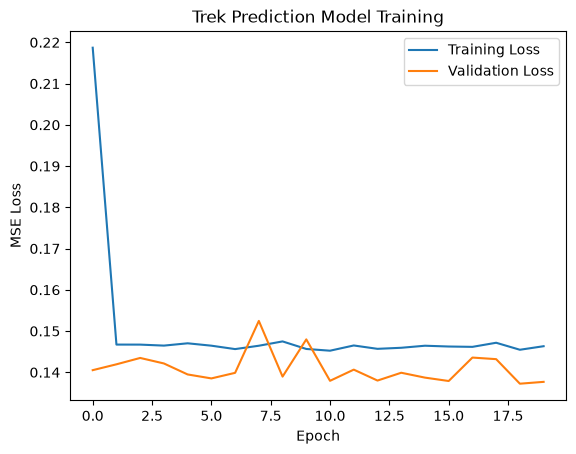

In [22]:
# Plot training and validation loss
import matplotlib.pyplot as plt
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Trek Prediction Model Training")
plt.legend()
plt.show()